# Quick Gradient Boosting Check
Minimal notebook to test GBM training and forecasting on hourly attraction data.


In [ ]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from modeling.wait_time_forecasting.paths import notebook_context
from modeling.wait_time_forecasting.data_preparation import prepare_train_df
from modeling.wait_time_forecasting.gradient_boosting import gbm_train, gbm_predict

ctx = notebook_context(project_root=PROJECT_ROOT)
PROJECT_ROOT = ctx["project_root"]
DATA_DIR = ctx["data_dir"]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)


In [ ]:
pack = prepare_train_df(data_dir=DATA_DIR, train_ratio=0.8)
train_df = pack['train_df']
test_df = pack['test_df']

attraction_name = str(train_df['ENTITY_DESCRIPTION_SHORT'].iloc[0])
print('train rows:', len(train_df))
print('test rows:', len(test_df))
print('split timestamp:', pack['split_timestamp'])


train rows: 238769
test rows: 55367
split timestamp: 2021-12-12 20:00:00


In [3]:
trained = gbm_train(
    train_df=train_df,
    attraction_name=attraction_name,
    validation_ratio=0.2,
    cv_splits=3,
    show_progress=True,
)

print('best params:', trained['best_params'])
print('validation MAE (CV mean):', trained['validation_mae'])
print('num feature cols:', len(trained['feature_cols']))
print('num candidate configs:', len(trained['candidate_scores']))

GBM CV [Bumper Cars]: [########################] 100% (36/36)
best params: {'n_estimators': 450, 'learning_rate': 0.03, 'max_depth': 4, 'subsample': 0.8, 'min_samples_leaf': 2}
validation MAE (CV mean): 3.23032593843613
num feature cols: 41
num candidate configs: 12


In [4]:
scores_df = pd.DataFrame(trained['candidate_scores']).copy()
scores_df = scores_df.sort_values('mae').reset_index(drop=True)
scores_df.head(10)

,params,mae,fold_mae
0,"{'n_estimators': 450, 'learning_rate': 0.03, '...",3.230326,"[3.5970427767744395, 2.432047793035968, 3.6618..."
1,"{'n_estimators': 350, 'learning_rate': 0.05, '...",3.286358,"[3.695856069083553, 2.416267411304737, 3.74695..."
2,"{'n_estimators': 400, 'learning_rate': 0.03, '...",3.307517,"[3.751733489844737, 2.429380492671767, 3.74143..."
3,"{'n_estimators': 250, 'learning_rate': 0.05, '...",3.314187,"[3.7491517796472387, 2.3949756711518098, 3.798..."
4,"{'n_estimators': 300, 'learning_rate': 0.03, '...",3.331033,"[3.8012341089306543, 2.4236162228206877, 3.768..."
5,"{'n_estimators': 200, 'learning_rate': 0.03, '...",3.336577,"[3.892656485015824, 2.387680412084358, 3.72939..."
6,"{'n_estimators': 400, 'learning_rate': 0.05, '...",3.376454,"[3.8720596203186943, 2.518866630670016, 3.7384..."
7,"{'n_estimators': 250, 'learning_rate': 0.03, '...",3.408843,"[4.027158922394029, 2.522211268429478, 3.67715..."
8,"{'n_estimators': 350, 'learning_rate': 0.03, '...",3.411908,"[3.9725383059304797, 2.551402002929608, 3.7117..."
9,"{'n_estimators': 200, 'learning_rate': 0.05, '...",3.417236,"[3.982555567698219, 2.5689281845977856, 3.7002..."


In [6]:
test_attr = test_df[test_df['ENTITY_DESCRIPTION_SHORT'].astype(str).eq(attraction_name)].copy()
test_attr = test_attr.sort_values('date_hour').reset_index(drop=True)

if test_attr.empty:
    raise ValueError('No test rows for selected attraction.')

y_true = pd.to_numeric(test_attr['wait_time_avg'], errors='coerce').reset_index(drop=True)
y_pred = gbm_predict(trained, test_attr).reset_index(drop=True)

mask = y_true.notna() & y_pred.notna()
if not mask.any():
    raise ValueError('No valid y_true/y_pred pairs.')

err = y_true[mask].to_numpy() - y_pred[mask].to_numpy()
mae = float(np.mean(np.abs(err)))
rmse = float(np.sqrt(np.mean(err ** 2)))

print('test rows for attraction:', len(test_attr))
print('valid eval rows:', int(mask.sum()))
print('MAE:', mae)
print('RMSE:', rmse)

test rows for attraction: 2908
valid eval rows: 2908
MAE: 3.8236278861951574
RMSE: 5.018441249450881


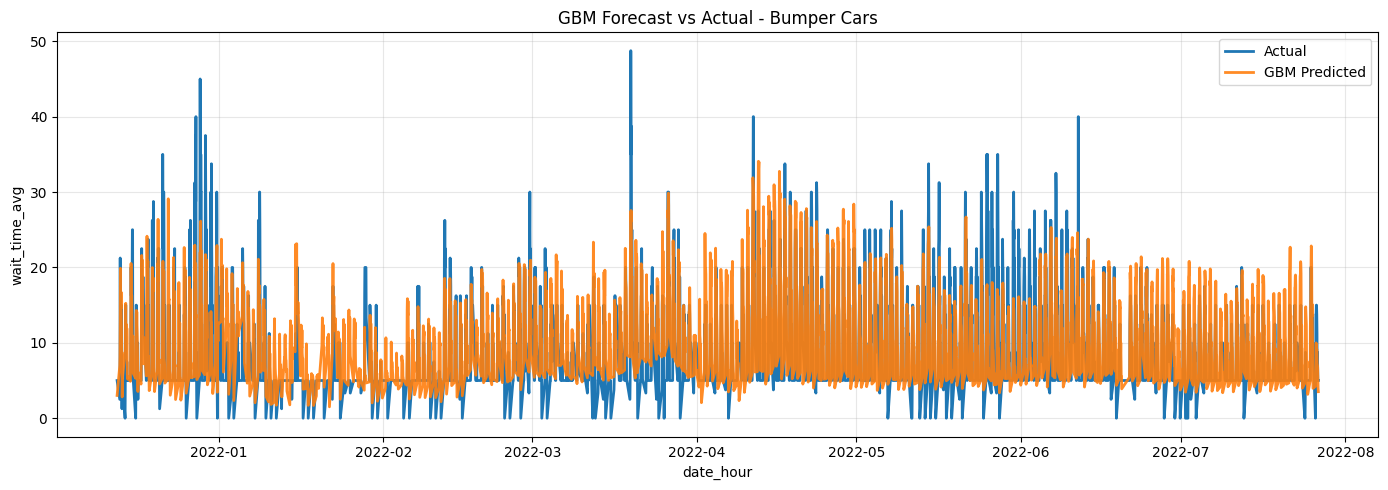

,date_hour,y_true,y_pred
0,2021-12-12 21:00:00,5.00,3.018749
1,2021-12-13 09:00:00,2.50,6.941056
2,2021-12-13 10:00:00,6.25,8.211502
3,2021-12-13 11:00:00,21.25,12.827233
4,2021-12-13 12:00:00,12.50,19.889638


In [7]:
pred_df = pd.DataFrame({
    'date_hour': pd.to_datetime(test_attr['date_hour'], errors='coerce').reset_index(drop=True),
    'y_true': y_true,
    'y_pred': y_pred,
})
pred_df = pred_df.sort_values('date_hour').reset_index(drop=True)

plt.figure(figsize=(14, 5))
plt.plot(pred_df['date_hour'], pred_df['y_true'], label='Actual', linewidth=2)
plt.plot(pred_df['date_hour'], pred_df['y_pred'], label='GBM Predicted', linewidth=2, alpha=0.9)
plt.title(f'GBM Forecast vs Actual - {attraction_name}')
plt.xlabel('date_hour')
plt.ylabel('wait_time_avg')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

pred_df.head()

## 7 days ahead


In [ ]:
test_attr = (
    test_df[test_df["ENTITY_DESCRIPTION_SHORT"].astype(str).eq(attraction_name)]
    .copy()
)
test_attr["date_hour"] = pd.to_datetime(test_attr["date_hour"], errors="coerce")
test_attr = test_attr.sort_values("date_hour").reset_index(drop=True)

if test_attr.empty:
    raise ValueError("No test rows for selected attraction.")

start_day = test_attr["date_hour"].dt.floor("D").min()
end_day_excl = start_day + pd.Timedelta(days=7)

test_7d = test_attr[
    (test_attr["date_hour"] >= start_day) &
    (test_attr["date_hour"] < end_day_excl)
].copy()

if test_7d.empty:
    raise ValueError("No rows found in the first 7-day window.")

y_true_7d = pd.to_numeric(test_7d["wait_time_avg"], errors="coerce").reset_index(drop=True)
y_pred_7d = gbm_predict(trained, test_7d).reset_index(drop=True)

mask = y_true_7d.notna() & y_pred_7d.notna()
if not mask.any():
    raise ValueError("No valid y_true/y_pred pairs in 7-day window.")

err = y_true_7d[mask].to_numpy() - y_pred_7d[mask].to_numpy()
mae_7d = float(np.mean(np.abs(err)))
rmse_7d = float(np.sqrt(np.mean(err ** 2)))

print("Window:", start_day.date(), "to", (end_day_excl - pd.Timedelta(days=1)).date())
print("Rows:", len(test_7d))
print("Valid eval rows:", int(mask.sum()))
print("MAE 7d:", mae_7d)
print("RMSE 7d:", rmse_7d)

pred_7d_df = pd.DataFrame({
    "date_hour": test_7d["date_hour"].reset_index(drop=True),
    "y_true": y_true_7d,
    "y_pred": y_pred_7d,
})
pred_7d_df.head()


Window: 2021-12-12 to 2021-12-18
Rows: 85
Valid eval rows: 85
MAE 7d: 3.6783979122055244
RMSE 7d: 4.955853204991702


,date_hour,y_true,y_pred
0,2021-12-12 21:00:00,5.00,3.018749
1,2021-12-13 09:00:00,2.50,6.941056
2,2021-12-13 10:00:00,6.25,8.211502
3,2021-12-13 11:00:00,21.25,12.827233
4,2021-12-13 12:00:00,12.50,19.889638


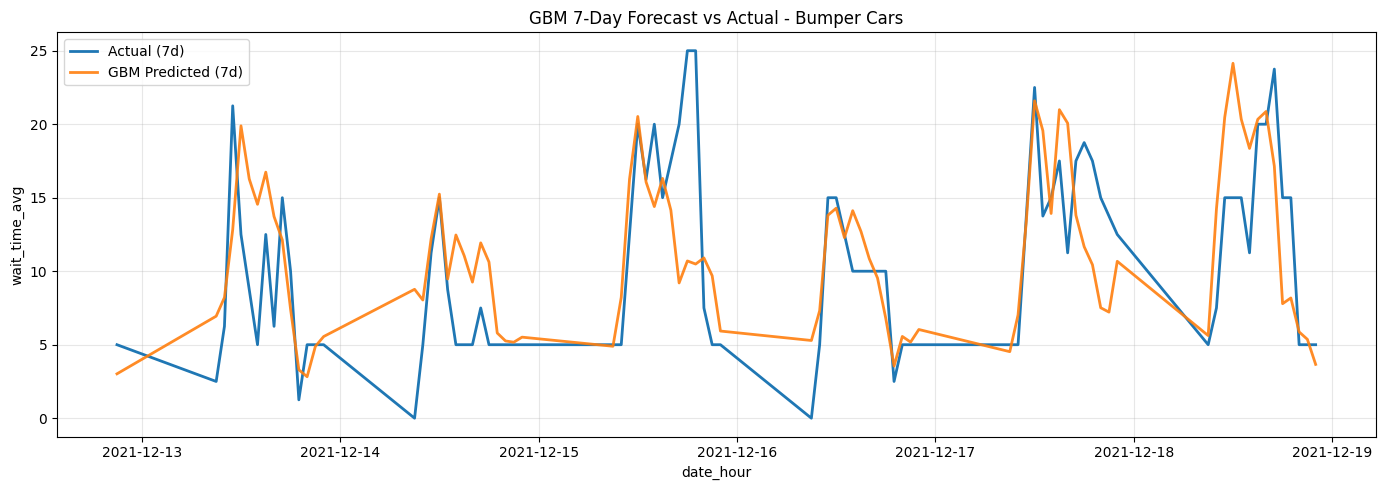

In [9]:
plot_7d = pred_7d_df.copy().sort_values("date_hour").reset_index(drop=True)

plt.figure(figsize=(14, 5))
plt.plot(plot_7d["date_hour"], plot_7d["y_true"], label="Actual (7d)", linewidth=2)
plt.plot(plot_7d["date_hour"], plot_7d["y_pred"], label="GBM Predicted (7d)", linewidth=2, alpha=0.9)

plt.title(f"GBM 7-Day Forecast vs Actual - {attraction_name}")
plt.xlabel("date_hour")
plt.ylabel("wait_time_avg")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
